In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
house = pd.read_csv('../datasets/housing.csv')

## Take a Quick Look at the Data Structure

In [3]:
house.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-114.31,34.19,15,5612,1283.0,1015,472,1.4936,66900,INLAND
1,-114.47,34.40,19,7650,1901.0,1129,463,1.8200,80100,INLAND
2,-114.49,33.97,17,2809,635.0,83,45,1.6154,87500,INLAND
3,-114.55,32.80,19,2570,820.0,1431,608,1.2750,56100,INLAND
4,-114.56,33.69,17,720,174.0,333,117,1.6509,85700,INLAND


In [8]:
house.loc[6000:60010,:]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
6000,-118.11,33.95,36,2049,334.0,1105,363,4.8036,261300,<1H OCEAN
6001,-118.11,33.95,34,2319,334.0,941,356,6.4319,452300,<1H OCEAN
6002,-118.11,33.95,34,1723,279.0,617,252,6.7501,400000,<1H OCEAN
6003,-118.11,33.96,29,2784,582.0,1278,550,4.3882,261600,<1H OCEAN
6004,-118.11,33.93,35,2670,493.0,1196,488,3.8427,283500,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
20635,-124.26,40.58,52,2217,394.0,907,369,2.3571,111400,NEAR OCEAN
20636,-124.27,40.69,36,2349,528.0,1194,465,2.5179,79000,NEAR OCEAN
20637,-124.30,41.80,19,2672,552.0,1298,478,1.9797,85800,NEAR OCEAN
20638,-124.30,41.84,17,2677,531.0,1244,456,3.0313,103600,NEAR OCEAN


In [9]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


### Checking null values

In [19]:
house.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
income_cat              0
dtype: int64

In [11]:
house['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [12]:
house.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

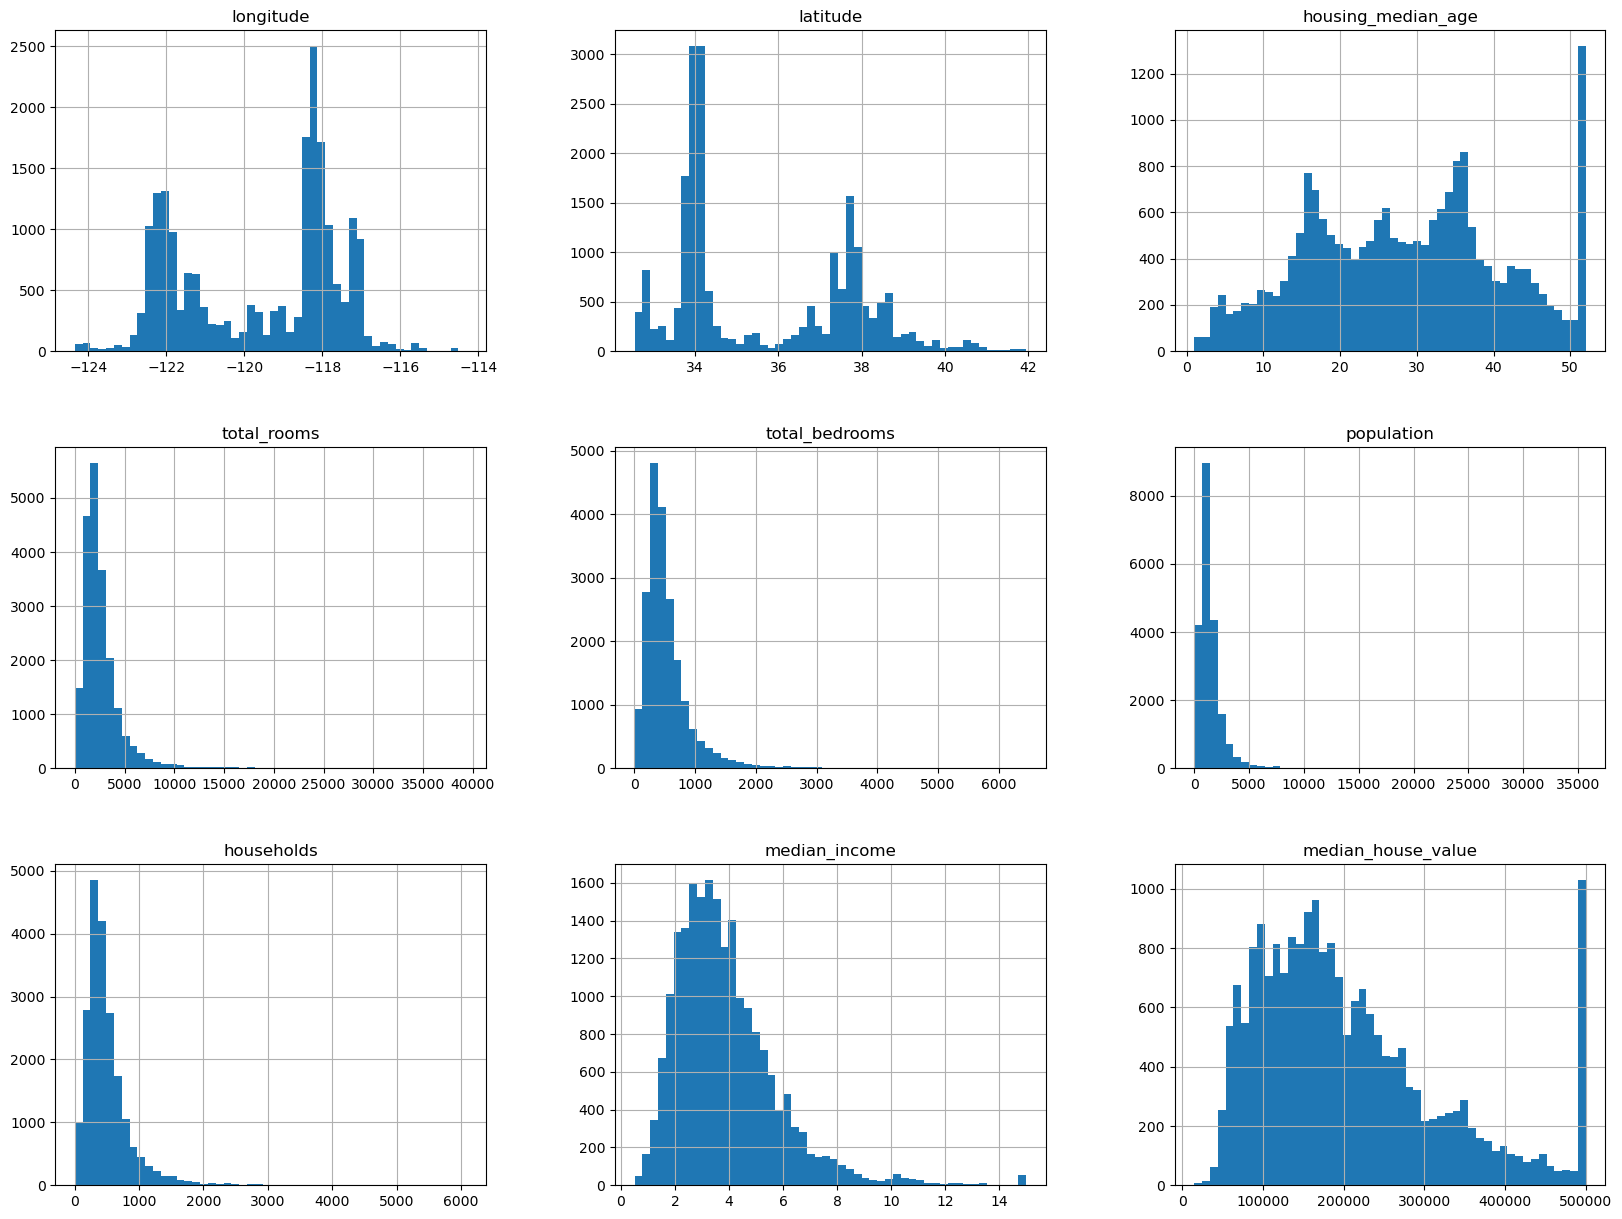

In [14]:
house.hist(bins = 50,figsize=(20,15))

## Spillting into train and test set

In [17]:
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [18]:
train_set, test_set = split_train_test(house,0.2)
print(len(train_set))
print(len(test_set))

16512
4128


In [21]:
train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16356.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.577989,35.638577,28.606771,2641.731892,538.589203,1428.253331,500.328488,3.872074,206926.900739
std,2.002673,2.137486,12.619643,2192.982751,422.729469,1146.541512,384.164669,1.900970,115865.910611
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,790.000000,279.000000,2.564300,118800.000000
50%,-118.500000,34.260000,29.000000,2129.000000,435.000000,1168.000000,410.000000,3.535100,179250.000000
75%,-118.010000,37.720000,37.000000,3164.250000,647.000000,1724.250000,605.000000,4.750000,265600.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [22]:
test_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,4128.000000,4128.000000,4128.000000,4128.000000,4077.000000,4128.000000,4128.000000,4128.000000,4128.000000
mean,-119.536567,35.605000,28.770349,2611.887839,534.987491,1414.370397,496.384448,3.865057,206571.481589
std,2.006862,2.129855,12.448939,2135.634924,415.986837,1074.362941,374.929565,1.895441,113508.371048
min,-124.300000,32.560000,2.000000,15.000000,5.000000,14.000000,4.000000,0.499900,14999.000000
25%,-121.760000,33.930000,19.000000,1448.000000,295.000000,780.750000,281.000000,2.560000,123200.000000
50%,-118.460000,34.240000,29.000000,2118.000000,431.000000,1161.000000,404.000000,3.533600,181300.000000
75%,-117.990000,37.692500,37.000000,3095.000000,645.000000,1726.000000,604.000000,4.715200,261650.000000
max,-114.490000,41.950000,52.000000,32054.000000,5419.000000,15507.000000,5050.000000,15.000100,500001.000000


# Using Sci-Kit-Learn

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
train_set, test_set = train_test_split(house , test_size=0.2 , random_state=42)

In [6]:
train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16348.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.566747,35.629784,28.585574,2632.037488,537.186445,1422.266957,498.608769,3.872722,206764.049479
std,2.004876,2.135539,12.609357,2171.274602,421.128737,1138.098476,382.535147,1.901672,115357.719933
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1441.000000,295.000000,785.000000,279.000000,2.564300,119800.000000
50%,-118.500000,34.260000,29.000000,2125.000000,434.000000,1163.000000,408.000000,3.535250,179500.000000
75%,-118.010000,37.710000,37.000000,3149.000000,646.000000,1721.000000,604.000000,4.742600,264100.000000
max,-114.470000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
test_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,4128.000000,4128.000000,4128.000000,4128.000000,4085.000000,4128.000000,4128.000000,4128.000000,4128.000000
mean,-119.581533,35.640170,28.855136,2650.665455,540.608323,1438.315891,503.263324,3.862466,207222.886628
std,1.998345,2.137844,12.489097,2222.701112,422.449908,1109.673405,381.530618,1.892611,115560.335348
min,-124.300000,32.550000,1.000000,15.000000,3.000000,9.000000,3.000000,0.499900,22500.000000
25%,-121.800000,33.940000,18.000000,1476.000000,298.000000,793.750000,283.000000,2.562500,119000.000000
50%,-118.480000,34.250000,29.000000,2132.000000,438.000000,1173.000000,415.000000,3.534100,180650.000000
75%,-118.010000,37.710000,37.000000,3141.000000,648.000000,1740.250000,606.000000,4.744800,267325.000000
max,-114.310000,41.860000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100,500001.000000


In [7]:
house['income_cat'] = pd.cut(house['median_income'] , bins=[0.,1.5,3.,4.5,6.,np.inf] , labels=[1,2,3,4,5])

In [8]:
train_set, test_set = train_test_split(house , test_size=0.2 , random_state=42)

<Axes: >

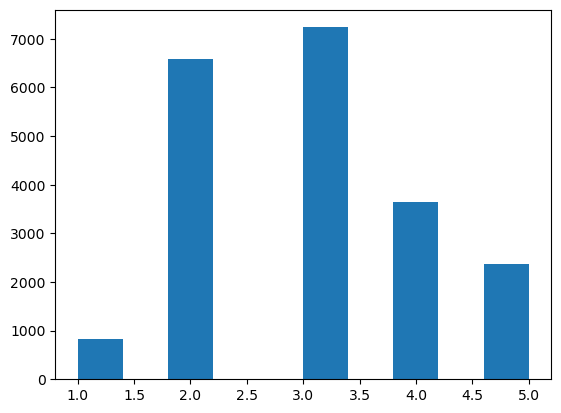

In [9]:
house['income_cat'].hist(grid=False)

In [10]:
from sklearn.model_selection import StratifiedShuffleSplit

splits = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

for train_idx , test_idx in splits.split(house,house['income_cat']):
    strat_train_set = house.loc[train_idx]
    strat_test_set = house.loc[test_idx]

In [11]:
strat_test_set['income_cat'].value_counts() / len(test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [12]:


compare_props = pd.DataFrame({
    "Overall": house['income_cat'].value_counts(normalize=True).sort_index(),
    "Stratified": strat_test_set['income_cat'].value_counts(normalize=True).sort_index(),
    "Random": test_set['income_cat'].value_counts(normalize=True).sort_index()
})

In [13]:
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

In [14]:
print(compare_props)

             Overall  Stratified    Random  Rand. %error  Strat. %error
income_cat                                                             
1           0.039826    0.039971  0.038760     -2.676399       0.364964
2           0.318847    0.318798  0.328004      2.871904      -0.015195
3           0.350581    0.350533  0.343508     -2.017689      -0.013820
4           0.176308    0.176357  0.176599      0.164880       0.027480
5           0.114438    0.114341  0.113130     -1.143099      -0.084674


In [15]:
## Droping income_set column

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [16]:
strat_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
12865,-120.47,37.96,25,2505,529.0,1145,483,2.0060,103000,INLAND
16358,-121.96,37.76,8,3865,463.0,1548,432,9.7037,425100,<1H OCEAN
3403,-117.72,33.62,19,1144,268.0,365,279,2.8583,105800,<1H OCEAN
13973,-121.27,38.74,19,3869,887.0,2086,685,2.6065,154900,INLAND
20488,-123.74,40.66,25,2395,431.0,983,375,3.0469,136000,<1H OCEAN


## Visualizing Geographical Data

<Axes: xlabel='longitude', ylabel='latitude'>

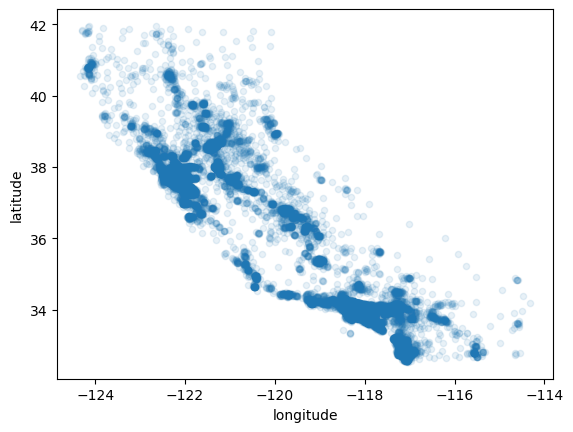

In [73]:
house.plot(kind="scatter", x="longitude", y="latitude" , alpha = 0.1)

### We can clearly see the high-density areas, namely the Bay Area and around Los Angeles and San Diego along with a long line of fairly high density in the Central Valley

<Axes: xlabel='longitude', ylabel='latitude'>

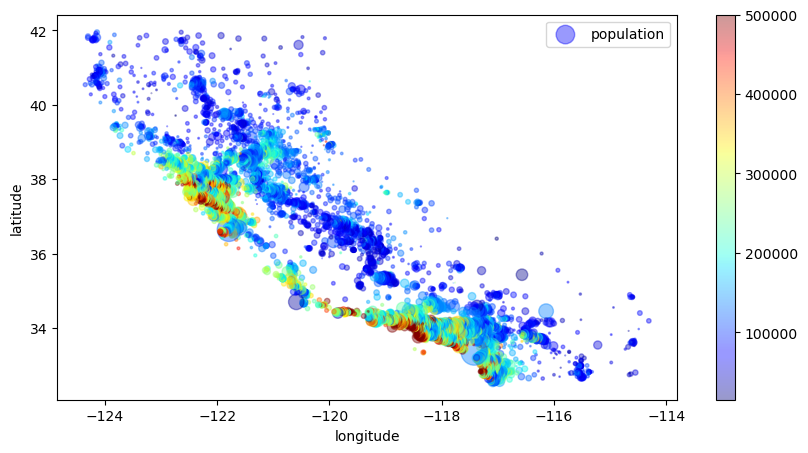

In [87]:
house.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=house["population"]/100,
    label="population",
    figsize=(10, 5),
    c=house["median_house_value"],  
    cmap="jet",                     
    colorbar=True,
   
)

# Correlations

In [89]:
corr_matrix = house.corr(numeric_only=True)

In [90]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


<Axes: >

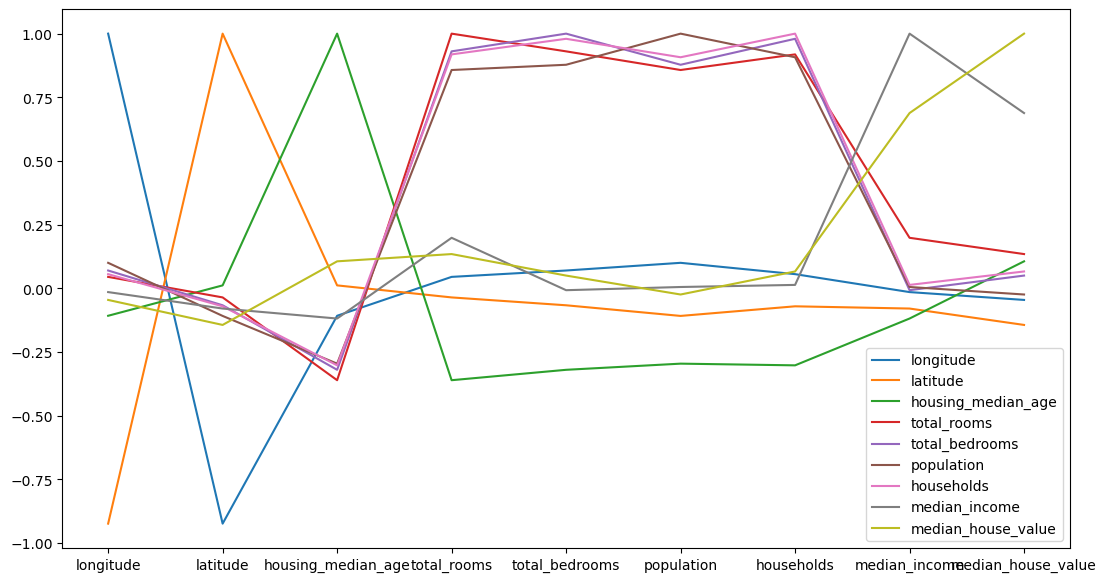

In [102]:
corr_matrix.plot(
    figsize=(13,7)
)

# Handling the missing values

In [17]:
housing = strat_train_set.drop('median_house_value',axis=1);


In [18]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
12865,-120.47,37.96,25,2505,529.0,1145,483,2.0060,INLAND
16358,-121.96,37.76,8,3865,463.0,1548,432,9.7037,<1H OCEAN
3403,-117.72,33.62,19,1144,268.0,365,279,2.8583,<1H OCEAN
13973,-121.27,38.74,19,3869,887.0,2086,685,2.6065,INLAND
20488,-123.74,40.66,25,2395,431.0,983,375,3.0469,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
15323,-121.74,37.35,34,440,90.0,217,93,5.2327,<1H OCEAN
12871,-120.48,37.29,17,2266,693.0,3200,664,1.5635,INLAND
19531,-122.45,38.27,25,5024,881.0,1994,838,4.2237,NEAR BAY
19428,-122.44,37.76,52,2110,454.0,816,438,3.9079,NEAR BAY


In [19]:
housing_lable = strat_train_set['median_house_value'].copy()

In [20]:
housing_lable

12865    103000
16358    425100
3403     105800
13973    154900
20488    136000
          ...  
15323    500001
12871     60400
19531    262300
19428    370000
19921    202800
Name: median_house_value, Length: 16512, dtype: int64

In [21]:
# housing.dropna(subset=["total_bedrooms"])     #  drop row where atleast 1 value is null   
# housing.drop("total_bedrooms", axis=1)        # drop whole column
median = housing["total_bedrooms"].median()   # storing median of that column 
housing["total_bedrooms"]=housing["total_bedrooms"].fillna(median)   # replacing that median in our dataframe

In [22]:
housing.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

## Now using sci-ki-learn

In [23]:
housing = strat_train_set.drop('median_house_value',axis=1);

In [24]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        163
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [25]:
from sklearn.impute import SimpleImputer

imputs = SimpleImputer(strategy='median')

housing_num = housing.drop("ocean_proximity", axis=1)

housing_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12865,-120.47,37.96,25,2505,529.0,1145,483,2.0060
16358,-121.96,37.76,8,3865,463.0,1548,432,9.7037
3403,-117.72,33.62,19,1144,268.0,365,279,2.8583
13973,-121.27,38.74,19,3869,887.0,2086,685,2.6065
20488,-123.74,40.66,25,2395,431.0,983,375,3.0469
...,...,...,...,...,...,...,...,...
15323,-121.74,37.35,34,440,90.0,217,93,5.2327
12871,-120.48,37.29,17,2266,693.0,3200,664,1.5635
19531,-122.45,38.27,25,5024,881.0,1994,838,4.2237
19428,-122.44,37.76,52,2110,454.0,816,438,3.9079


In [26]:
imputs.fit(housing_num)

imputs.statistics_

array([-118.5   ,   34.26  ,   29.    , 2135.5   ,  435.    , 1167.    ,
        410.    ,    3.5313])

In [27]:
X=imputs.transform(housing_num)

In [28]:
new_housing = pd.DataFrame(X, columns=housing_num.columns,index=housing_num.index)

In [29]:
new_housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12865,-120.47,37.96,25.0,2505.0,529.0,1145.0,483.0,2.0060
16358,-121.96,37.76,8.0,3865.0,463.0,1548.0,432.0,9.7037
3403,-117.72,33.62,19.0,1144.0,268.0,365.0,279.0,2.8583
13973,-121.27,38.74,19.0,3869.0,887.0,2086.0,685.0,2.6065
20488,-123.74,40.66,25.0,2395.0,431.0,983.0,375.0,3.0469
...,...,...,...,...,...,...,...,...
15323,-121.74,37.35,34.0,440.0,90.0,217.0,93.0,5.2327
12871,-120.48,37.29,17.0,2266.0,693.0,3200.0,664.0,1.5635
19531,-122.45,38.27,25.0,5024.0,881.0,1994.0,838.0,4.2237
19428,-122.44,37.76,52.0,2110.0,454.0,816.0,438.0,3.9079


# Real Life Analogy

- SimpleImputer(...) → buys a calculator 🧮
- fit() → calculates medians
- transform() → applies those medians to fill missing values

## Checking for categorical columns

In [30]:
housing_cat = housing[["ocean_proximity"]]

In [31]:
housing_cat.head(10)

,ocean_proximity
12865,INLAND
16358,<1H OCEAN
3403,<1H OCEAN
13973,INLAND
20488,<1H OCEAN
1438,NEAR OCEAN
17874,NEAR BAY
4368,<1H OCEAN
17904,INLAND
7871,<1H OCEAN


In [32]:
# convert these categories from text to numbers using Scikit-Learn’s OrdinalEncoder class

from sklearn.preprocessing import OrdinalEncoder

In [33]:
ordinal_encoder = OrdinalEncoder()

housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [34]:
housing_cat_encoded[:10]

array([[1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [4.],
       [3.],
       [0.],
       [1.],
       [0.]])

In [35]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [36]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [38]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [39]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.]], shape=(16512, 5))

In [40]:
cat_encoder.categories_


[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [41]:
housing_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12865,-120.47,37.96,25,2505,529.0,1145,483,2.0060
16358,-121.96,37.76,8,3865,463.0,1548,432,9.7037
3403,-117.72,33.62,19,1144,268.0,365,279,2.8583
13973,-121.27,38.74,19,3869,887.0,2086,685,2.6065
20488,-123.74,40.66,25,2395,431.0,983,375,3.0469
...,...,...,...,...,...,...,...,...
15323,-121.74,37.35,34,440,90.0,217,93,5.2327
12871,-120.48,37.29,17,2266,693.0,3200,664,1.5635
19531,-122.45,38.27,25,5024,881.0,1994,838,4.2237
19428,-122.44,37.76,52,2110,454.0,816,438,3.9079


## Training and Evaluating on the Training Set

In [42]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

housing_num = housing.drop("ocean_proximity", axis=1)

housing_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12865,-120.47,37.96,25,2505,529.0,1145,483,2.0060
16358,-121.96,37.76,8,3865,463.0,1548,432,9.7037
3403,-117.72,33.62,19,1144,268.0,365,279,2.8583
13973,-121.27,38.74,19,3869,887.0,2086,685,2.6065
20488,-123.74,40.66,25,2395,431.0,983,375,3.0469
...,...,...,...,...,...,...,...,...
15323,-121.74,37.35,34,440,90.0,217,93,5.2327
12871,-120.48,37.29,17,2266,693.0,3200,664,1.5635
19531,-122.45,38.27,25,5024,881.0,1994,838,4.2237
19428,-122.44,37.76,52,2110,454.0,816,438,3.9079


In [43]:
housing_num_imputed = imputer.fit_transform(housing_num)

housing_num_imputed

array([[-120.47  ,   37.96  ,   25.    , ..., 1145.    ,  483.    ,
           2.006 ],
       [-121.96  ,   37.76  ,    8.    , ..., 1548.    ,  432.    ,
           9.7037],
       [-117.72  ,   33.62  ,   19.    , ...,  365.    ,  279.    ,
           2.8583],
       ...,
       [-122.45  ,   38.27  ,   25.    , ..., 1994.    ,  838.    ,
           4.2237],
       [-122.44  ,   37.76  ,   52.    , ...,  816.    ,  438.    ,
           3.9079],
       [-122.54  ,   38.36  ,   40.    , ..., 1167.    ,  458.    ,
           3.7969]], shape=(16512, 8))

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
housing_prepared = scaler.fit_transform(housing_num_imputed)

housing_prepared

array([[-0.44424794,  1.08229031, -0.2891691 , ..., -0.24547513,
        -0.03939223, -0.98061585],
       [-1.18591613,  0.98890495, -1.63985672, ...,  0.11168524,
        -0.17463136,  3.0674623 ],
       [ 0.92460275, -0.94417194, -0.76588238, ..., -0.93675327,
        -0.58034874, -0.53240703],
       ...,
       [-1.42982043,  1.22703762, -0.2891691 , ...,  0.50695453,
         0.90197817,  0.18563159],
       [-1.42484279,  0.98890495,  1.85604065, ..., -0.53705271,
        -0.15872087,  0.01955821],
       [-1.47461918,  1.26906103,  0.90261409, ..., -0.22597755,
        -0.10568592, -0.03881464]], shape=(16512, 8))

In [61]:
housing_prepared_df = pd.DataFrame(housing_prepared,index=housing.index)

housing_prepared_df

,0,1,2,3,4,5,6,7
12865,-0.444248,1.082290,-0.289169,-0.056309,-0.013976,-0.245475,-0.039392,-0.980616
16358,-1.185916,0.988905,-1.639857,0.579016,-0.173828,0.111685,-0.174631,3.067462
3403,0.924603,-0.944172,-0.765882,-0.692100,-0.646119,-0.936753,-0.580349,-0.532407
13973,-0.842459,1.446493,-0.765882,0.580884,0.853102,0.588490,0.496261,-0.664824
20488,-2.071936,2.342993,-0.289169,-0.107695,-0.251333,-0.389048,-0.325781,-0.433226
...,...,...,...,...,...,...,...,...
15323,-1.076408,0.797465,0.425901,-1.020974,-1.077236,-1.067919,-1.073574,0.716246
12871,-0.449226,0.769449,-0.924787,-0.167958,0.383233,1.575777,0.440574,-1.213318
19531,-1.429820,1.227038,-0.289169,1.120443,0.838570,0.506955,0.901978,0.185632
19428,-1.424843,0.988905,1.856041,-0.240833,-0.195626,-0.537053,-0.158721,0.019558


In [45]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(housing_prepared , housing_lable)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
data = housing.iloc[:5]

labels = housing_lable.iloc[:5]



In [53]:
print("Prediction : " , lin_reg.predict(housing_prepared[:5]))

Prediction :  [ 78071.12541033 402841.97138086 173610.57227773  96686.06661659
 135065.40469007]


In [54]:
print("Labels : " , list(labels))

Labels :  [103000, 425100, 105800, 154900, 136000]


In [56]:
from sklearn.metrics import mean_squared_error

house_pred = lin_reg.predict(housing_prepared)

lin_mse = mean_squared_error(housing_lable , house_pred)

lin_rmse = np.sqrt(lin_mse)

lin_rmse

np.float64(69616.46089527188)